In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 1_boston_housing.csv to 1_boston_housing.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df = pd.read_csv('1_boston_housing.csv')

In [ ]:
df.columns = df.columns.str.replace('"', ' ')

In [ ]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

In [ ]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer= 'adam', loss='mse', metrics=['mae'])

In [ ]:
history=model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.2, verbose = 1)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 480.0302 - mae: 20.8371 - val_loss: 453.0145 - val_mae: 20.3346
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 479.0013 - mae: 20.8158 - val_loss: 452.1432 - val_mae: 20.3160
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 478.0124 - mae: 20.7964 - val_loss: 451.2787 - val_mae: 20.2974
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 477.0146 - mae: 20.7756 - val_loss: 450.4300 - val_mae: 20.2785
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 476.0664 - mae: 20.7553 - val_loss: 449.5317 - val_mae: 20.2590
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 475.0978 - mae: 20.7349 - val_loss: 448.6875 - val_mae: 20.2404
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 474.1187 - mae: 20.7142 - val_loss: 447.8234 - val_mae: 20.2213
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 473.1472 - mae: 20.6940 - val_loss: 446.9990 - val_mae: 20.2029
Epoch 9/1

In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 375.4248 - mae: 18.5510 
Test Loss: 375.4248
Test MAE: 18.5510


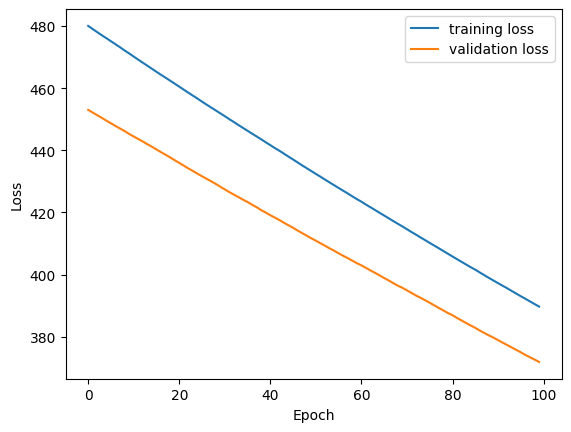

In [ ]:
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()